In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

#Датасет

In [ ]:
raw=''
datadir='data/'
files=['cards_data.csv','users_data.csv','transactions_data.csv']

In [ ]:
d2=pd.read_csv(raw+files[2])
d2.amount = d2.amount.str.replace('$', '').astype(float)
d2.errors = d2.errors.fillna('Okay')

In [ ]:
target = pd.read_json('train_fraud_labels.json')

# Сортировка по индексу
target = target.sort_index()

# Проверка
print(target.head())
print(f"Индексы: от {target.index.min()} до {target.index.max()}")

        target
7475327     No
7475328     No
7475329     No
7475332     No
7475333     No
Индексы: от 7475327 до 23761870


In [ ]:
d2 = d2[d2['id'].isin(target.index)]

In [ ]:
d2

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,Okay
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,Okay
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,Okay
4,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,Okay
5,7475333,2010-01-01 00:07:00,1807,165,4.81,Swipe Transaction,20519,Bronx,NY,10464.0,5942,Okay
...,...,...,...,...,...,...,...,...,...,...,...,...
13305905,23761862,2019-10-31 23:54:00,672,5001,12.93,Chip Transaction,47508,Cosby,TN,37722.0,7230,Okay
13305906,23761863,2019-10-31 23:54:00,1384,3723,67.01,Chip Transaction,58136,Williamson,GA,30292.0,5812,Okay
13305910,23761868,2019-10-31 23:56:00,1718,2379,1.11,Chip Transaction,86438,West Covina,CA,91792.0,5499,Okay
13305911,23761869,2019-10-31 23:56:00,1766,2066,12.80,Online Transaction,39261,ONLINE,NaN,NaN,5815,Okay


In [ ]:
d2 = d2.merge(target, left_on='id', right_index=True, how='inner')

In [ ]:
d2

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,target
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,Okay,No
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,Okay,No
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,Okay,No
4,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,Okay,No
5,7475333,2010-01-01 00:07:00,1807,165,4.81,Swipe Transaction,20519,Bronx,NY,10464.0,5942,Okay,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13305905,23761862,2019-10-31 23:54:00,672,5001,12.93,Chip Transaction,47508,Cosby,TN,37722.0,7230,Okay,No
13305906,23761863,2019-10-31 23:54:00,1384,3723,67.01,Chip Transaction,58136,Williamson,GA,30292.0,5812,Okay,No
13305910,23761868,2019-10-31 23:56:00,1718,2379,1.11,Chip Transaction,86438,West Covina,CA,91792.0,5499,Okay,No
13305911,23761869,2019-10-31 23:56:00,1766,2066,12.80,Online Transaction,39261,ONLINE,NaN,NaN,5815,Okay,No


In [ ]:
gc.collect()

202

In [ ]:
d1=pd.read_csv(raw+files[1])
for bucks in ['per_capita_income','yearly_income','total_debt']:
    d1[bucks] = d1[bucks].str.replace('$', '').astype(float)
d1.rename(columns={'id':'client_id'}, inplace=True)

In [ ]:
d2

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,Okay
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,Okay
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,Okay
3,7475331,2010-01-01 00:05:00,430,2860,200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,Okay
4,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,Okay
...,...,...,...,...,...,...,...,...,...,...,...,...
13305910,23761868,2019-10-31 23:56:00,1718,2379,1.11,Chip Transaction,86438,West Covina,CA,91792.0,5499,Okay
13305911,23761869,2019-10-31 23:56:00,1766,2066,12.80,Online Transaction,39261,ONLINE,NaN,NaN,5815,Okay
13305912,23761870,2019-10-31 23:57:00,199,1031,40.44,Swipe Transaction,2925,Allen,TX,75002.0,4900,Okay
13305913,23761873,2019-10-31 23:58:00,1986,5443,4.00,Chip Transaction,46284,Daly City,CA,94014.0,5411,Okay


In [ ]:
data=pd.merge(d2, d1, on='client_id', how='left')

In [ ]:
del d1, d2

In [ ]:
gc.collect()

50

In [ ]:
d0=pd.read_csv(raw+files[0])
d0.has_chip = np.where(d0.has_chip.values == 'YES', 1, 0)
d0.card_on_dark_web = np.where(d0.card_on_dark_web.values == 'No', 0, 1)
d0.credit_limit = d0.credit_limit.str.replace('$', '').astype(float)
d0.expires=pd.to_datetime(d0.expires, format='%M/%Y').dt.date
d0.acct_open_date=pd.to_datetime(d0.acct_open_date, format='%M/%Y').dt.date
d0.rename(columns={'id':'card_id'}, inplace=True)

In [ ]:
data=pd.merge(data, d0.drop('client_id', axis=1), on='card_id', how='left').drop('id', axis=1)

In [ ]:
del d0
gc.collect()

35

In [ ]:
data

,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,...,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,...,Debit (Prepaid),5497590243197280,2022-01-01,306,1,2,55.0,2008-01-01,2008,0
1,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,...,Credit,5175842699412235,2024-01-01,438,1,1,9100.0,2005-01-01,2015,0
2,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,...,Debit,5874992802287595,2020-01-01,256,1,1,14802.0,2006-01-01,2008,0
3,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,...,Debit,4354185735186651,2020-01-01,120,1,1,19113.0,2009-01-01,2014,0
4,2010-01-01 00:07:00,1807,165,4.81,Swipe Transaction,20519,Bronx,NY,10464.0,5942,...,Debit (Prepaid),5207231566469664,2014-01-01,198,1,1,89.0,2008-01-01,2015,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8914958,2019-10-31 23:54:00,672,5001,12.93,Chip Transaction,47508,Cosby,TN,37722.0,7230,...,Debit,4598597915590543,2020-01-01,17,1,1,8333.0,2003-01-01,2007,0
8914959,2019-10-31 23:54:00,1384,3723,67.01,Chip Transaction,58136,Williamson,GA,30292.0,5812,...,Debit,4025390379737737,2020-01-01,473,1,2,24617.0,2004-01-01,2006,0
8914960,2019-10-31 23:56:00,1718,2379,1.11,Chip Transaction,86438,West Covina,CA,91792.0,5499,...,Debit,5766352389579834,2020-01-01,992,1,1,26743.0,2019-01-01,2019,0
8914961,2019-10-31 23:56:00,1766,2066,12.80,Online Transaction,39261,ONLINE,NaN,NaN,5815,...,Debit,5960254965868032,2024-01-01,91,1,1,5141.0,2004-01-01,2012,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8914963 entries, 0 to 8914962
Data columns (total 36 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   date                   object 
 1   client_id              int64  
 2   card_id                int64  
 3   amount                 float64
 4   use_chip               object 
 5   merchant_id            int64  
 6   merchant_city          object 
 7   merchant_state         object 
 8   zip                    float64
 9   mcc                    int64  
 10  errors                 object 
 11  target                 object 
 12  current_age            int64  
 13  retirement_age         int64  
 14  birth_year             int64  
 15  birth_month            int64  
 16  gender                 object 
 17  address                object 
 18  latitude               float64
 19  longitude              float64
 20  per_capita_income      float64
 21  yearly_income          float64
 22  total_debt        

In [ ]:
data["date"] = pd.to_datetime(data["date"])

In [ ]:
data["hour"] = data["date"].dt.hour
data["is_night"] = data["hour"].apply(lambda x: 1 if 0 <= x <= 4 else 0)
data["is_weekend"] = data["date"].dt.weekday >= 5

In [ ]:
data

,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,...,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web,hour,is_night,is_weekend
0,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,...,306,1,2,55.0,2008-01-01,2008,0,0,1,False
1,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,...,438,1,1,9100.0,2005-01-01,2015,0,0,1,False
2,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,...,256,1,1,14802.0,2006-01-01,2008,0,0,1,False
3,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,...,120,1,1,19113.0,2009-01-01,2014,0,0,1,False
4,2010-01-01 00:07:00,1807,165,4.81,Swipe Transaction,20519,Bronx,NY,10464.0,5942,...,198,1,1,89.0,2008-01-01,2015,0,0,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8914958,2019-10-31 23:54:00,672,5001,12.93,Chip Transaction,47508,Cosby,TN,37722.0,7230,...,17,1,1,8333.0,2003-01-01,2007,0,23,0,False
8914959,2019-10-31 23:54:00,1384,3723,67.01,Chip Transaction,58136,Williamson,GA,30292.0,5812,...,473,1,2,24617.0,2004-01-01,2006,0,23,0,False
8914960,2019-10-31 23:56:00,1718,2379,1.11,Chip Transaction,86438,West Covina,CA,91792.0,5499,...,992,1,1,26743.0,2019-01-01,2019,0,23,0,False
8914961,2019-10-31 23:56:00,1766,2066,12.80,Online Transaction,39261,ONLINE,NaN,NaN,5815,...,91,1,1,5141.0,2004-01-01,2012,0,23,0,False


In [ ]:
data["year"] = data["date"].dt.year

###в этот момент я сохраняю данные

In [ ]:
data.to_csv('my_data.csv', index=False)

In [ ]:
from google.colab import files

In [ ]:
files.download('my_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
gc.collect()

67

### можно загрузить

In [ ]:
data = pd.read_csv("my_data.csv")

### удаление лишних и добавление нужных признаков

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8914963 entries, 0 to 8914962
Data columns (total 40 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   date                   object 
 1   client_id              int64  
 2   card_id                int64  
 3   amount                 float64
 4   use_chip               object 
 5   merchant_id            int64  
 6   merchant_city          object 
 7   merchant_state         object 
 8   zip                    float64
 9   mcc                    int64  
 10  errors                 object 
 11  target                 object 
 12  current_age            int64  
 13  retirement_age         int64  
 14  birth_year             int64  
 15  birth_month            int64  
 16  gender                 object 
 17  address                object 
 18  latitude               float64
 19  longitude              float64
 20  per_capita_income      float64
 21  yearly_income          float64
 22  total_debt        

In [ ]:
data["date"] = pd.to_datetime(data["date"])

In [ ]:
data["acct_open_date"] = pd.to_datetime(data["acct_open_date"])

In [ ]:
data["expires"] = pd.to_datetime(data["expires"])

In [ ]:
data['days_from_open'] = (data['date'] - data['acct_open_date']).dt.days

In [ ]:
data['days_to_expire'] = (data['expires'] - data['date']).dt.days

In [ ]:
data.drop("date", axis=1, inplace=True)

In [ ]:
data.drop("acct_open_date", axis=1, inplace=True)

In [ ]:
data.drop("expires", axis=1, inplace=True)

In [ ]:
data["years_since_pin_changed"] = data["year"] - data["year_pin_last_changed"]

In [ ]:
data.drop("year_pin_last_changed", axis=1, inplace=True)

In [ ]:
gc.collect()

0

In [ ]:
data.is_weekend = np.where(data.is_weekend.values == 'No', 0, 1)

In [ ]:
data.target = np.where(data.target.values == 'No', 0, 1)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8914963 entries, 0 to 8914962
Data columns (total 39 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   client_id                int64  
 1   card_id                  int64  
 2   amount                   float64
 3   use_chip                 object 
 4   merchant_id              int64  
 5   merchant_city            object 
 6   merchant_state           object 
 7   zip                      float64
 8   mcc                      int64  
 9   errors                   object 
 10  target                   int64  
 11  current_age              int64  
 12  retirement_age           int64  
 13  birth_year               int64  
 14  birth_month              int64  
 15  gender                   object 
 16  address                  object 
 17  latitude                 float64
 18  longitude                float64
 19  per_capita_income        float64
 20  yearly_income            float64
 21  total_de

###в этот момент я сохраняю данные ещё раз

In [ ]:
data.to_csv('data_cleaned.csv', index=False)

In [ ]:
data.to_csv('drive/MyDrive/data_cleaned.csv', index=False)

In [ ]:
data = pd.read_csv("data_cleaned.csv")

#Уменьшенный датасет

Уменьшение размера датасета до 1млн

In [ ]:
# Разделяем данные на fraud (target=1) и non-fraud (target=0)
fraud_data = data[data['target'] == 1]
non_fraud_data = data[data['target'] == 0]

# Считаем количество fraud записей
n_fraud = len(fraud_data)
print(f"Количество fraud записей: {n_fraud}")

# Целевой размер датасета
target_size = 1_000_000

# Сколько non-fraud записей нужно добавить
n_non_fraud_needed = target_size - n_fraud

# Если нужно больше non-fraud записей, чем есть
if n_non_fraud_needed > len(non_fraud_data):
    print(f"Внимание: недостаточно non-fraud записей. Доступно: {len(non_fraud_data)}")
    n_non_fraud_needed = len(non_fraud_data)

# Случайная выборка из non-fraud данных
non_fraud_sampled = non_fraud_data.sample(n=n_non_fraud_needed, random_state=42)

# Объединяем и перемешиваем
reduced_data = pd.concat([fraud_data, non_fraud_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Итоговый размер датасета: {len(reduced_data)}")
print(f"Распределение target:\n{reduced_data['target'].value_counts()}")

Количество fraud записей: 13332
Итоговый размер датасета: 1000000
Распределение target:
target
0    986668
1     13332
Name: count, dtype: int64


In [ ]:
reduced_data

,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,...,num_cards_issued,credit_limit,card_on_dark_web,hour,is_night,is_weekend,year,days_from_open,days_to_expire,years_since_pin_changed
0,1699,2204,11.84,Swipe Transaction,57758,San Jose,CA,95134.0,4121,Okay,...,1,60610.0,0,11,0,1,2012,1527,3586,4
1,114,3398,31.50,Chip Transaction,33234,North Hollywood,CA,91606.0,5812,Okay,...,2,27447.0,0,18,0,1,2015,2896,2582,5
2,62,3369,40.38,Swipe Transaction,56148,San Francisco,CA,94129.0,5812,Okay,...,1,1559.0,0,18,0,1,2010,1319,4524,0
3,641,2774,12.68,Chip Transaction,41943,Columbus,OH,43228.0,5813,Okay,...,2,18401.0,0,10,0,1,2017,224,505,0
4,1362,2145,18.68,Swipe Transaction,81185,Burke,VA,22015.0,5411,Okay,...,2,29708.0,0,11,0,1,2012,1886,1766,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1498,2232,317.00,Chip Transaction,7777,White Plains,NY,10603.0,3684,Okay,...,1,22227.0,0,23,0,1,2018,3293,358,8
999996,53,3581,22.36,Online Transaction,15143,ONLINE,NaN,NaN,4784,Okay,...,2,16923.0,0,17,0,1,2017,1112,2539,3
999997,0,4639,5.96,Swipe Transaction,13153,Scarborough,ME,4074.0,5812,Okay,...,1,17600.0,0,19,0,1,2010,1280,3102,-4
999998,794,3430,61.00,Swipe Transaction,61195,South Gate,CA,90280.0,5541,Okay,...,2,11164.0,0,13,0,1,2010,453,276,0


###сохранение укороченного датасета

In [ ]:
reduced_data.to_csv('reduced_dataa.csv', index=False)

In [1]:
reduced_data.to_csv('drive/MyDrive/reduced_dataa.csv', index=False)

NameError: name 'reduced_data' is not defined

In [2]:
reduced_data = pd.read_csv("drive/MyDrive/reduced_dataa.csv")

#Baseline (Дерево решений)

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, f1_score, classification_report

In [4]:
y = reduced_data['target']
X = reduced_data.drop('target', axis=1)

In [5]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 38 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   client_id                1000000 non-null  int64  
 1   card_id                  1000000 non-null  int64  
 2   amount                   1000000 non-null  float64
 3   use_chip                 1000000 non-null  object 
 4   merchant_id              1000000 non-null  int64  
 5   merchant_city            1000000 non-null  object 
 6   merchant_state           875899 non-null   object 
 7   zip                      866184 non-null   float64
 8   mcc                      1000000 non-null  int64  
 9   errors                   1000000 non-null  object 
 10  current_age              1000000 non-null  int64  
 11  retirement_age           1000000 non-null  int64  
 12  birth_year               1000000 non-null  int64  
 13  birth_month              1000000 non-null  

In [6]:
object_columns = X.select_dtypes(include=['object']).columns.tolist()
print("Object columns to encode:", object_columns)

# 3. Преобразуем object колонки в числа с помощью Label Encoding
label_encoders = {}
for col in object_columns:
    le = LabelEncoder()
    # Обрабатываем возможные NaN значения
    X[col] = X[col].fillna('missing')  # заполняем пропуски
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le  # сохраняем для обратного преобразования

# 4. Обрабатываем другие пропущенные значения (если есть)
# merchant_state и zip имеют пропуски, заполняем их
for col in X.columns:
    if X[col].dtype in ['int64', 'float64']:
        X[col] = X[col].fillna(X[col].median())  # для числовых
    elif X[col].dtype == 'object':
        X[col] = X[col].fillna('missing')  # если остались object

# 5. Проверяем результат
print("\nПосле обработки:")
print(X.info())
print("\nПервые несколько строк:")
print(X.head())

Object columns to encode: ['use_chip', 'merchant_city', 'merchant_state', 'errors', 'gender', 'address', 'card_brand', 'card_type']

После обработки:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 38 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   client_id                1000000 non-null  int64  
 1   card_id                  1000000 non-null  int64  
 2   amount                   1000000 non-null  float64
 3   use_chip                 1000000 non-null  int64  
 4   merchant_id              1000000 non-null  int64  
 5   merchant_city            1000000 non-null  int64  
 6   merchant_state           1000000 non-null  int64  
 7   zip                      1000000 non-null  float64
 8   mcc                      1000000 non-null  int64  
 9   errors                   1000000 non-null  int64  
 10  current_age              1000000 non-null  int64  
 11  retir

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

###Тест

=== ОСНОВНЫЕ МЕТРИКИ ===
Accuracy: 0.9964
F1 Score (weighted): 0.9964


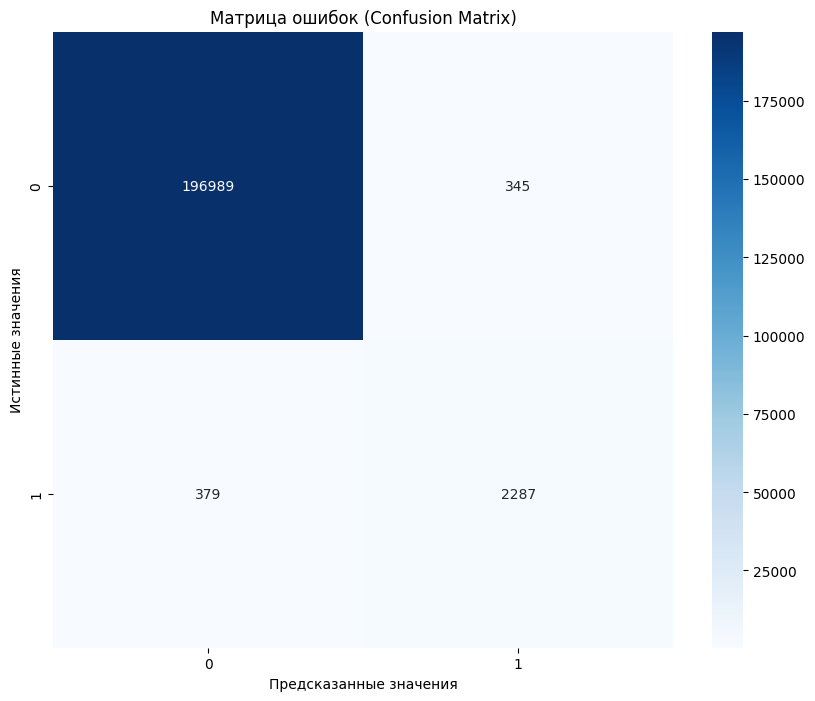


=== ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССИФИКАЦИИ ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    197334
           1       0.87      0.86      0.86      2666

    accuracy                           1.00    200000
   macro avg       0.93      0.93      0.93    200000
weighted avg       1.00      1.00      1.00    200000


=== МЕТРИКИ ПО КЛАССАМ ===
Класс 0:
  Precision: 0.9981
  Recall: 0.9983
  F1-score: 0.9982
Класс 1:
  Precision: 0.8689
  Recall: 0.8578
  F1-score: 0.8633

=== АНАЛИЗ ОШИБОК (бинарная классификация) ===
True Negatives (TN): 196989
False Positives (FP): 345
False Negatives (FN): 379
True Positives (TP): 2287
Sensitivity (Recall): 0.8578
Specificity: 0.9983


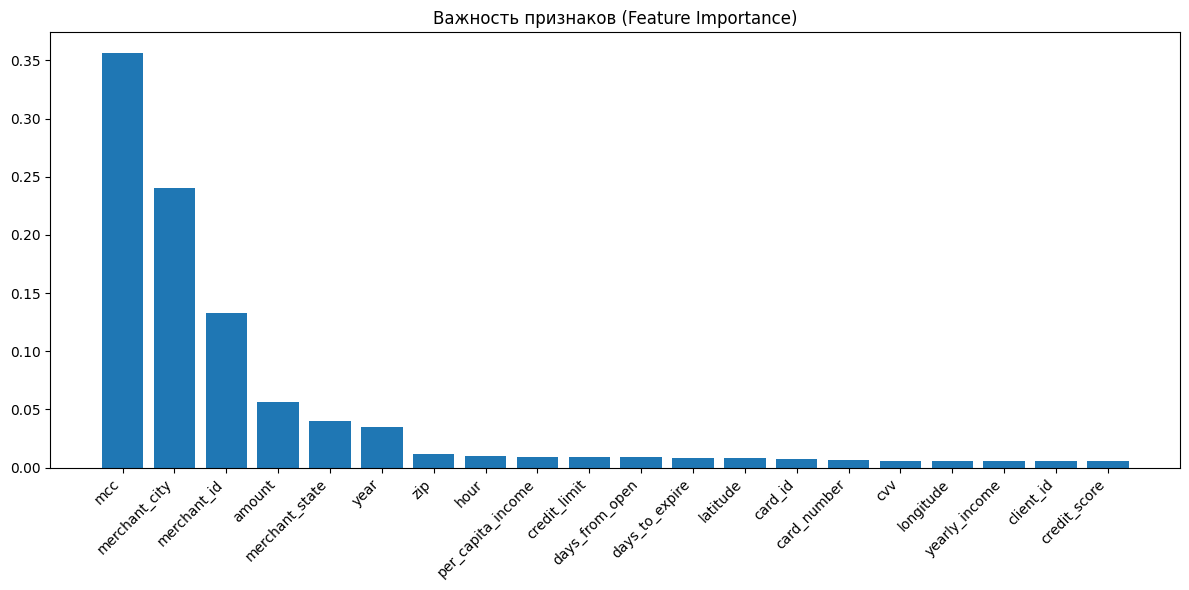

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

y_pred = model.predict(X_test)

# 2. Получаем вероятности предсказаний (опционально)
y_pred_proba = model.predict_proba(X_test)

# 3. Основные метрики
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')  # для многоклассовой классификации
# Для бинарной классификации можно использовать: f1 = f1_score(y_test, y_pred)

print("=== ОСНОВНЫЕ МЕТРИКИ ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score (weighted): {f1:.4f}")

# 4. Матрица ошибок (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

# 5. Детальный отчет по классификации
print("\n=== ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССИФИКАЦИИ ===")
print(classification_report(y_test, y_pred))

# 6. Метрики для каждого класса (если нужно)
print("\n=== МЕТРИКИ ПО КЛАССАМ ===")
classes = np.unique(y_test)
for i, class_name in enumerate(classes):
    # Создаем бинарные метки для текущего класса
    y_test_binary = (y_test == class_name).astype(int)
    y_pred_binary = (y_pred == class_name).astype(int)

    precision = precision_score(y_test_binary, y_pred_binary, zero_division=0)
    recall = recall_score(y_test_binary, y_pred_binary, zero_division=0)
    f1_class = f1_score(y_test_binary, y_pred_binary, zero_division=0)

    print(f"Класс {class_name}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-score: {f1_class:.4f}")

# 7. Анализ ошибок (пример для бинарной классификации)
if len(classes) == 2:
    tn, fp, fn, tp = cm.ravel()

    print("\n=== АНАЛИЗ ОШИБОК (бинарная классификация) ===")
    print(f"True Negatives (TN): {tn}")
    print(f"False Positives (FP): {fp}")
    print(f"False Negatives (FN): {fn}")
    print(f"True Positives (TP): {tp}")

    # Дополнительные метрики
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Чувствительность (Recall)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # Специфичность

    print(f"Sensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")

# 8. Визуализация важности признаков (для Decision Tree)
feature_importance = model.feature_importances_
feature_names = X_train.columns

# Сортируем признаки по важности
indices = np.argsort(feature_importance)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Важность признаков (Feature Importance)")
plt.bar(range(min(20, len(feature_names))),
        feature_importance[indices][:20])
plt.xticks(range(min(20, len(feature_names))),
           [feature_names[i] for i in indices[:20]],
           rotation=45, ha='right')
plt.tight_layout()
plt.show()

###Если логарифмировать суммы

In [ ]:
X_2_train = X_train.copy()
X_2_train["amount"] = np.log2(np.fabs(X_train["amount"]) + 1e-10)

In [ ]:
X_2_test = X_test.copy()
X_2_test["amount"] = np.log2(np.fabs(X_test["amount"]) + 1e-10)

In [ ]:
model_log = DecisionTreeClassifier(random_state=42)
model_log.fit(X_2_train, y_train)

DecisionTreeClassifier(random_state=42)

=== ОСНОВНЫЕ МЕТРИКИ ===
Accuracy: 0.9964
F1 Score (weighted): 0.9913


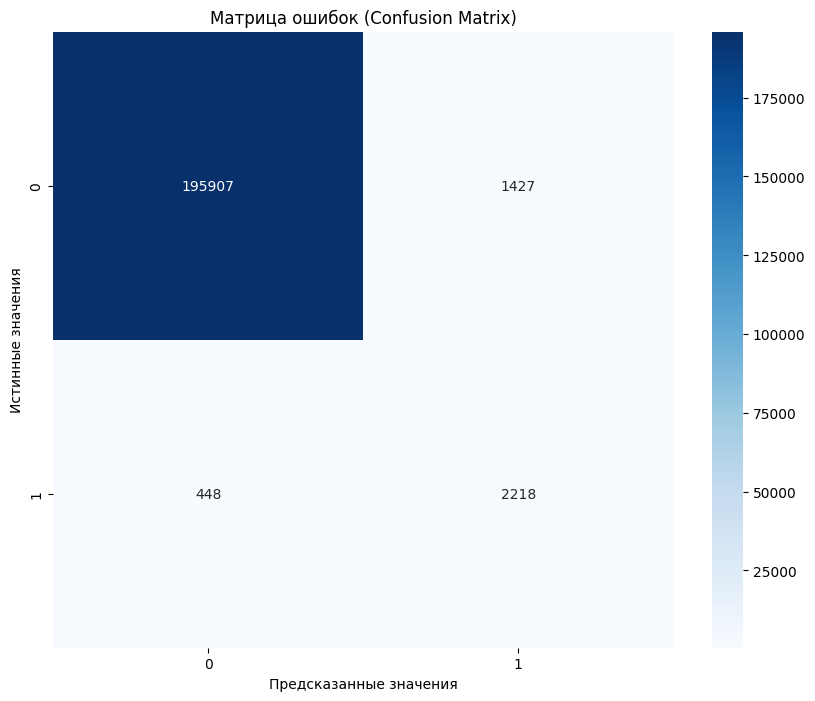


=== ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССИФИКАЦИИ ===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    197334
           1       0.61      0.83      0.70      2666

    accuracy                           0.99    200000
   macro avg       0.80      0.91      0.85    200000
weighted avg       0.99      0.99      0.99    200000


=== МЕТРИКИ ПО КЛАССАМ ===
Класс 0:
  Precision: 0.8689
  Recall: 0.8578
  F1-score: 0.8633
Класс 1:
  Precision: 0.8689
  Recall: 0.8578
  F1-score: 0.8633

=== АНАЛИЗ ОШИБОК (бинарная классификация) ===
True Negatives (TN): 195907
False Positives (FP): 1427
False Negatives (FN): 448
True Positives (TP): 2218
Sensitivity (Recall): 0.8320
Specificity: 0.9928


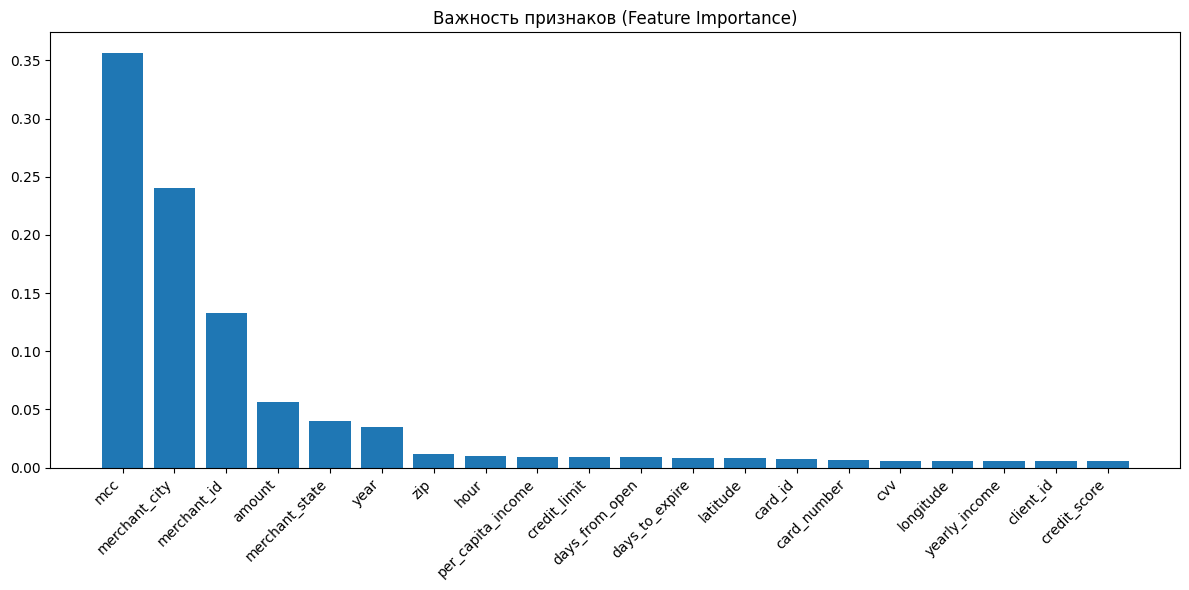

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

y_2_pred = model.predict(X_2_test)

# 2. Получаем вероятности предсказаний (опционально)
y_2_pred_proba = model.predict_proba(X_2_test)

# 3. Основные метрики
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_2_pred, average='weighted')  # для многоклассовой классификации
# Для бинарной классификации можно использовать: f1 = f1_score(y_test, y_pred)

print("=== ОСНОВНЫЕ МЕТРИКИ ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score (weighted): {f1:.4f}")

# 4. Матрица ошибок (Confusion Matrix)
cm = confusion_matrix(y_test, y_2_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

# 5. Детальный отчет по классификации
print("\n=== ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССИФИКАЦИИ ===")
print(classification_report(y_test, y_2_pred))

# 6. Метрики для каждого класса (если нужно)
print("\n=== МЕТРИКИ ПО КЛАССАМ ===")
classes = np.unique(y_test)
for i, class_name in enumerate(classes):
    # Создаем бинарные метки для текущего класса
    y_test_binary = (y_test == class_name).astype(int)
    y_2_pred_binary = (y_2_pred == class_name).astype(int)

    precision_2 = precision_score(y_test_binary, y_2_pred_binary, zero_division=0)
    recall_2 = recall_score(y_test_binary, y_2_pred_binary, zero_division=0)
    f1_class_2 = f1_score(y_test_binary, y_2_pred_binary, zero_division=0)

    print(f"Класс {class_name}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-score: {f1_class:.4f}")

# 7. Анализ ошибок (пример для бинарной классификации)
if len(classes) == 2:
    tn, fp, fn, tp = cm.ravel()

    print("\n=== АНАЛИЗ ОШИБОК (бинарная классификация) ===")
    print(f"True Negatives (TN): {tn}")
    print(f"False Positives (FP): {fp}")
    print(f"False Negatives (FN): {fn}")
    print(f"True Positives (TP): {tp}")

    # Дополнительные метрики
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Чувствительность (Recall)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # Специфичность

    print(f"Sensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")

# 8. Визуализация важности признаков (для Decision Tree)
feature_importance = model.feature_importances_
feature_names = X_2_train.columns

# Сортируем признаки по важности
indices = np.argsort(feature_importance)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Важность признаков (Feature Importance)")
plt.bar(range(min(20, len(feature_names))),
        feature_importance[indices][:20])
plt.xticks(range(min(20, len(feature_names))),
           [feature_names[i] for i in indices[:20]],
           rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
for i in range(38):
  if feature_importance[i] < 0.006:
    print(f"{feature_names[i]}, ")

client_id, 
use_chip, 
errors, 
current_age, 
retirement_age, 
birth_year, 
birth_month, 
gender, 
address, 
longitude, 
yearly_income, 
total_debt, 
credit_score, 
num_credit_cards, 
card_brand, 
card_type, 
cvv, 
has_chip, 
num_cards_issued, 
card_on_dark_web, 
is_night, 
is_weekend, 
years_since_pin_changed, 


In [ ]:
X['mcc'].unique()

array([4121, 5812, 5813, 5411, 4829, 5651, 5541, 5912, 7538, 5814, 5499,
       4784, 5310, 4214, 5732, 4111, 4814, 5311, 4899, 8111, 5621, 7995,
       5719, 5942, 8011, 9402, 5970, 4722, 5300, 7832, 8043, 4900, 5211,
       5815, 7542, 5921, 5045, 8041, 3395, 3722, 7922, 6300, 5251, 3359,
       5932, 3009, 8021, 7230, 3596, 7349, 3780, 5094, 5941, 8099, 7276,
       5192, 3509, 5947, 5712, 4112, 3504, 7011, 5193, 3730, 3684, 3640,
       3405, 3387, 3058, 5661, 3775, 7801, 3144, 7802, 8049, 7210, 3000,
       3771, 3390, 5977, 5655, 3066, 4131, 4411, 7393, 3174, 3393, 7996,
       3001, 5816, 5261, 3389, 3132, 1711, 3256, 3005, 5533, 5733, 3008,
       8062, 4511, 3007, 5722, 8931, 3260, 3006, 7549, 3075, 7531])

#Сеть Хопфилда 1

In [7]:
X = np.abs(X)

In [8]:
X

,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,...,num_cards_issued,credit_limit,card_on_dark_web,hour,is_night,is_weekend,year,days_from_open,days_to_expire,years_since_pin_changed
0,1699,2204,11.84,2,57758,7184,19,95134.0,4121,18,...,1,60610.0,0,11,0,1,2012,1527,3586,4
1,114,3398,31.50,0,33234,5750,19,91606.0,5812,18,...,2,27447.0,0,18,0,1,2015,2896,2582,5
2,62,3369,40.38,2,56148,7179,19,94129.0,5812,18,...,1,1559.0,0,18,0,1,2010,1319,4524,0
3,641,2774,12.68,0,41943,1646,112,43228.0,5813,18,...,2,18401.0,0,10,0,1,2017,224,505,0
4,1362,2145,18.68,2,81185,1017,163,22015.0,5411,18,...,2,29708.0,0,11,0,1,2012,1886,1766,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1498,2232,317.00,0,7777,8798,105,10603.0,3684,18,...,1,22227.0,0,23,0,1,2018,3293,358,8
999996,53,3581,22.36,1,15143,5830,175,47805.0,4784,18,...,2,16923.0,0,17,0,1,2017,1112,2539,3
999997,0,4639,5.96,2,13153,7286,81,4074.0,5812,18,...,1,17600.0,0,19,0,1,2010,1280,3102,4
999998,794,3430,61.00,2,61195,7633,19,90280.0,5541,18,...,2,11164.0,0,13,0,1,2010,453,276,0


In [9]:
maxes = np.max(X, axis=0)

In [10]:
mins = np.min(X, axis=0)

In [11]:
maxes

,0
client_id,1.998000e+03
card_id,6.138000e+03
amount,4.978450e+03
use_chip,2.000000e+00
merchant_id,1.003400e+05
merchant_city,9.085000e+03
merchant_state,1.750000e+02
zip,9.992800e+04
mcc,9.402000e+03
errors,1.900000e+01


In [12]:
X = X - mins

In [13]:
np.min(X, axis=0)

,0
client_id,0.0
card_id,0.0
amount,0.0
use_chip,0.0
merchant_id,0.0
merchant_city,0.0
merchant_state,0.0
zip,0.0
mcc,0.0
errors,0.0


In [14]:
columns_to_drop = [
    'client_id', 'use_chip', 'errors', 'current_age', 'retirement_age',
    'birth_year', 'birth_month', 'gender', 'address', 'longitude',
    'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards',
    'card_brand', 'card_type', 'cvv', 'has_chip', 'num_cards_issued',
    'card_on_dark_web', 'is_night', 'is_weekend', 'years_since_pin_changed'
]

X_dropped = X.drop(columns=columns_to_drop)

In [ ]:
X_dropped

,card_id,amount,merchant_id,merchant_city,merchant_state,zip,mcc,latitude,per_capita_income,card_number,credit_limit,hour,year,days_from_open,days_to_expire
0,2204.0,11.84,57755.0,7184.0,19.0,94133.0,2410.0,16.12,51631.0,4.395219e+15,60610.0,11.0,2.0,1527.0,3586.0
1,3398.0,31.50,33231.0,5750.0,19.0,90605.0,4101.0,12.88,16892.0,5.263183e+15,27447.0,18.0,5.0,2896.0,2582.0
2,3369.0,40.38,56145.0,7179.0,19.0,93128.0,4101.0,19.83,15296.0,3.928231e+15,1559.0,18.0,0.0,1319.0,4524.0
3,2774.0,12.68,41940.0,1646.0,112.0,42227.0,4102.0,18.68,18420.0,3.790632e+15,18401.0,10.0,7.0,224.0,505.0
4,2145.0,18.68,81182.0,1017.0,163.0,21014.0,3700.0,17.48,35563.0,5.266590e+15,29708.0,11.0,2.0,1886.0,1766.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2232.0,317.00,7774.0,8798.0,105.0,9602.0,1973.0,18.38,24911.0,3.838825e+15,22227.0,23.0,8.0,3293.0,358.0
999996,3581.0,22.36,15140.0,5830.0,175.0,46804.0,3073.0,17.32,19471.0,5.371170e+15,16923.0,17.0,7.0,1112.0,2539.0
999997,4639.0,5.96,13150.0,7286.0,81.0,3073.0,4101.0,22.29,29237.0,5.502654e+15,17600.0,19.0,0.0,1280.0,3102.0
999998,3430.0,61.00,61192.0,7633.0,19.0,89279.0,3830.0,12.64,14528.0,5.494060e+15,11164.0,13.0,0.0,453.0,276.0


In [15]:
maxes_dropped = np.max(X_dropped, axis=0)

In [16]:
maxes_dropped

,0
card_id,6.138000e+03
amount,4.978450e+03
merchant_id,1.003370e+05
merchant_city,9.085000e+03
merchant_state,1.750000e+02
zip,9.892700e+04
mcc,7.691000e+03
latitude,2.723000e+01
per_capita_income,1.631450e+05
card_number,6.694112e+15


In [17]:
X_dropped['card_number'] = X_dropped['card_number'] % 1000000

In [18]:
maxes_dropped = np.max(X_dropped, axis=0)

In [19]:
maxes_dropped

,0
card_id,6138.00
amount,4978.45
merchant_id,100337.00
merchant_city,9085.00
merchant_state,175.00
zip,98927.00
mcc,7691.00
latitude,27.23
per_capita_income,163145.00
card_number,999810.00


In [20]:
sizes = (np.log2(maxes_dropped) + 1).astype(int)

In [21]:
X_dropped = X_dropped.astype(int)

In [22]:
sizes

,0
card_id,13
amount,13
merchant_id,17
merchant_city,14
merchant_state,8
zip,17
mcc,13
latitude,5
per_capita_income,18
card_number,20


In [23]:
sum(sizes)

192

In [24]:
first_row = X_dropped.iloc[0]

In [26]:
def to_binar_vec(sizes, values):
    """
    Конкатенирует двоичные представления значений с выравниванием по заданной длине.

    Parameters:
    -----------
    sizes : list или array
        Вектор размеров (требуемая длина каждого двоичного представления)
    values : list или array
        Вектор значений для преобразования в двоичный формат

    Returns:
    --------
    vec : list
        Вектор - конкатенация двоичных представлений
    """
    vec = []

    for size, value in zip(sizes, values):
        # Получаем двоичное представление числа без префикса '0b'
        binary = bin(value)[2:]

        # Если длина двоичного представления меньше требуемой, добавляем нули слева
        if len(binary) < size:
            binary = '0' * (size - len(binary)) + binary

        # Добавляем каждый символ как отдельный элемент в результирующий вектор
        vec.extend([int(bit) for bit in binary])

    current_length = len(vec)

    next_square = int(np.ceil(np.sqrt(current_length)) ** 2)

    # Добавляем нули
    if next_square > current_length:
        vec = np.pad(vec, (0, next_square - current_length), 'constant', constant_values=0)

    return np.asarray(vec)

In [27]:
to_binar_vec(sizes, first_row).shape

(196,)

In [28]:
X_dropped

,card_id,amount,merchant_id,merchant_city,merchant_state,zip,mcc,latitude,per_capita_income,card_number,credit_limit,hour,year,days_from_open,days_to_expire
0,2204,11,57755,7184,19,94133,2410,16,51631,767640,60610,11,2,1527,3586
1,3398,31,33231,5750,19,90605,4101,12,16892,989432,27447,18,5,2896,2582
2,3369,40,56145,7179,19,93128,4101,19,15296,752812,1559,18,0,1319,4524
3,2774,12,41940,1646,112,42227,4102,18,18420,872284,18401,10,7,224,505
4,2145,18,81182,1017,163,21014,3700,17,35563,924736,29708,11,2,1886,1766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2232,317,7774,8798,105,9602,1973,18,24911,583066,22227,23,8,3293,358
999996,3581,22,15140,5830,175,46804,3073,17,19471,46956,16923,17,7,1112,2539
999997,4639,5,13150,7286,81,3073,4101,22,29237,699426,17600,19,0,1280,3102
999998,3430,61,61192,7633,19,89279,3830,12,14528,83145,11164,13,0,453,276


Сохранение X_dropped

In [ ]:
X_dropped.to_csv('X_dropped.csv', index=False)

In [ ]:
X_dropped.to_csv('drive/MyDrive/X_dropped.csv', index=False)

In [29]:
# Если X_dropped - это матрица (образцы × признаки)
# И sizes соответствует каждому признаку
def process_multiple_objects(X_dropped, sizes):
    """
    Обрабатывает несколько объектов (строк матрицы X_dropped)

    Parameters:
    -----------
    X_dropped : array-like, shape (n_samples, n_features)
        Матрица с данными
    sizes : array-like, shape (n_features,)
        Размеры двоичных представлений для каждого признака

    Returns:
    --------
    X_binar : array, shape (n_samples, total_bits)
        Матрица с двоичными представлениями
    """
    X_binar_list = []

    for i in range(len(X_dropped)):
        if i % 100000 == 0:
            print(i)
            print('\n')
        vec = to_binar_vec(sizes, X_dropped.iloc[i])
        X_binar_list.append(vec)

    return np.array(X_binar_list)

# Применяем функцию
X_binar_matrix = process_multiple_objects(X_dropped, sizes)

print(f"Форма исходных данных: {X_dropped.shape}")
print(f"Форма двоичных данных: {X_binar_matrix.shape}")

0


100000


200000


300000


400000


500000


600000


700000


800000


900000


Форма исходных данных: (1000000, 15)
Форма двоичных данных: (1000000, 196)


In [30]:
y.shape

(1000000,)

###сохранение бинарной матрицы

In [ ]:
df = pd.DataFrame(X_binar_matrix)
df.to_csv('drive/MyDrive/X_binar_matrix.csv', index=False)

In [ ]:
y.to_csv('drive/MyDrive/y_for_binar_matrix.csv', index=False)

In [3]:
X_binar_matrix = pd.read_csv("drive/MyDrive/X_binar_matrix.csv")

In [4]:
y = pd.read_csv("drive/MyDrive/y_for_binar_matrix.csv")

In [31]:
X_binar_matrix_train, X_binar_matrix_test, y_train, y_test = train_test_split(X_binar_matrix, y, test_size=0.2, random_state=42, stratify=y)

In [32]:
X_fraud_matrix = X_binar_matrix_train[y_train == 1]
X_legit_matrix = X_binar_matrix_train[y_train == 0]

In [33]:
X_fraud_matrix.shape

(10666, 196)

In [34]:
X_legit_matrix.shape

(789334, 196)

##Выбор паттернов

In [64]:
from sklearn.cluster import MiniBatchKMeans # Используем MiniBatch для скорости на 10k данных
import numpy as np

n_fraud_clusters = 4

fraud_kmeans = MiniBatchKMeans(n_clusters=n_fraud_clusters, random_state=42, batch_size=1024)
fraud_kmeans.fit(X_fraud_matrix)

# Паттерны для сети Хопфилда - это центроиды кластеров
fraud_patterns = fraud_kmeans.cluster_centers_

# ВАЖНО: Центроиды K-Means обычно типа float (координаты центра).
# Для сети Хопфилда их нужно преобразовать обратно в биполярный вид (+1, -1).
# Порог: если значение в центроиде > 0.5, считаем за 1, иначе -1.
fraud_patterns_bipolar = np.where(fraud_patterns > 0.5, 1, -1).astype(np.int8)

In [65]:
# Случайно отбираем 200k строк из легитимных
legit_sample_indices = np.random.choice(780000, size=200000, replace=False)
X_legit_sample = X_legit_matrix[legit_sample_indices]

n_legit_clusters = 6

legit_kmeans = MiniBatchKMeans(n_clusters=n_legit_clusters, random_state=42, batch_size=4096)
legit_kmeans.fit(X_legit_sample)

legit_patterns = legit_kmeans.cluster_centers_
legit_patterns_bipolar = np.where(legit_patterns > 0.5, 1, -1).astype(np.int8)

In [66]:
all_patterns = np.vstack([fraud_patterns_bipolar, legit_patterns_bipolar])

print(f"Всего паттернов: {len(all_patterns)}")
print(f"Мошеннических: {len(fraud_patterns_bipolar)}")
print(f"Легитимных: {len(legit_patterns_bipolar)}")

Всего паттернов: 10
Мошеннических: 4
Легитимных: 6


In [67]:
from scipy.spatial.distance import hamming

dist = hamming(fraud_patterns_bipolar[0], legit_patterns_bipolar[0])
print(f"Расстояние Хэмминга: {dist}")

Расстояние Хэмминга: 0.37755102040816324


In [68]:
N = 196  # количество нейронов (признаков)
M = len(all_patterns) # количество паттернов

# Инициализация матрицы весов
W = np.zeros((N, N))

# Аккумуляция весов по правилу Хебба
for p in all_patterns:
    # Внешнее произведение вектора самого на себя
    # p должен быть формы (N, 1) для вычисления p * p.T
    p_col = p.reshape(-1, 1)
    W += np.dot(p_col, p_col.T)

# Нормализация (деление на N) и обнуление диагонали
W = W / N
np.fill_diagonal(W, 0)

In [69]:
import numpy as np
from scipy.spatial.distance import hamming

def hopfield_converge(sample, W, patterns, max_it=100, threshold=0):
    """
    Функция для сходимости сети Хопфилда к одному из эталонных паттернов.

    Parameters:
    -----------
    sample : np.ndarray
        Входной бинарный вектор (значения 0/1 или -1/1) формы (N,)
    W : np.ndarray
        Матрица весов сети Хопфилда формы (N, N)
    patterns : np.ndarray
        Матрица эталонных паттернов формы (M, N) в биполярном виде (-1/1)
    max_it : int
        Максимальное количество итераций
    threshold : float
        Порог для функции активации (обычно 0 для биполярных векторов)

    Returns:
    --------
    tuple:
        - pattern_idx: int - индекс паттерна в матрице patterns, к которому сошлась сеть
        - min_distance: float - расстояние Хэмминга до этого паттерна
        - converged_state: np.ndarray - финальное состояние сети
        - n_iterations: int - количество выполненных итераций
        - distances_history: list - история расстояний до всех паттернов (опционально)
    """

    # Приведение входного вектора к биполярному виду, если он бинарный (0/1)
    sample_bipolar = sample.copy()
    if np.any((sample == 0) | (sample == 1)):  # если значения 0 или 1
        sample_bipolar = np.where(sample == 0, -1, 1).astype(np.int8)

    # Проверка размерности
    assert len(sample_bipolar) == W.shape[0] == W.shape[1], "Размерности не совпадают"
    assert patterns.shape[1] == len(sample_bipolar), "Размерность паттернов не совпадает"

    # Текущее состояние
    state = sample_bipolar.copy()
    prev_state = np.zeros_like(state)

    # Для отслеживания динамики
    distances_history = []
    n_iterations = 0
    pattern_idx = -1
    min_distance = float('inf')

    # Асинхронное обновление (последовательное)
    for iteration in range(max_it):
        # Сохраняем предыдущее состояние для проверки сходимости
        prev_state = state.copy()

        # Асинхронное обновление: обновляем нейроны по одному в случайном порядке
        # Это более реалистично для сети Хопфилда и помогает избежать циклов
        neuron_order = np.random.permutation(len(state))

        for i in neuron_order:
            # Вычисляем взвешенную сумму входов (net_i)
            net_i = np.dot(W[i, :], state) - threshold

            # Функция активации (знаковая для биполярных значений)
            if net_i > 0:
                state[i] = 1
            elif net_i < 0:
                state[i] = -1
            # если net_i == 0, состояние не меняется (можно оставить как есть)

        # Вычисляем расстояния до всех эталонных паттернов
        distances = np.array([hamming(state, p) for p in patterns])
        min_dist_idx = np.argmin(distances)
        current_min_dist = distances[min_dist_idx]

        distances_history.append({
            'iteration': iteration,
            'min_distance': current_min_dist,
            'closest_pattern': min_dist_idx,
            'all_distances': distances.copy()
        })

        # Проверка сходимости: если состояние не изменилось за итерацию
        if np.array_equal(state, prev_state):
            pattern_idx = min_dist_idx
            min_distance = current_min_dist
            n_iterations = iteration + 1
            break

    # Если достигли max_it без сходимости
    if n_iterations == 0:  # если не было break
        # Берем ближайший паттерн на последней итерации
        final_distances = np.array([hamming(state, p) for p in patterns])
        pattern_idx = np.argmin(final_distances)
        min_distance = final_distances[pattern_idx]
        n_iterations = max_it

    return pattern_idx, min_distance, state, n_iterations, distances_history


def hopfield_converge_batch(samples, W, patterns, max_it=100, threshold=0):
    """
    Пакетная обработка нескольких образцов.

    Parameters:
    -----------
    samples : np.ndarray
        Матрица входных векторов формы (n_samples, N)

    Returns:
    --------
    list of tuples - результаты для каждого образца
    """
    results = []
    for i, sample in enumerate(samples):
        result = hopfield_converge(sample, W, patterns, max_it, threshold)
        results.append(result)

        if (i + 1) % 100 == 0:
            print(f"Обработано {i + 1}/{len(samples)} образцов")

    return results


# Упрощенная версия только с номером паттерна и расстоянием
def hopfield_predict(sample, W, patterns, max_it=100, threshold=0):
    """
    Упрощенная версия, возвращает только индекс ближайшего паттерна и расстояние.
    """
    pattern_idx, min_distance, _, _, _ = hopfield_converge(
        sample, W, patterns, max_it, threshold
    )
    return pattern_idx, min_distance


In [79]:
hopfield_predict(X_binar_matrix_test[16509], W, all_patterns)

(np.int64(9), np.float64(0.15816326530612246))

In [81]:
y_test.iloc[16509]

np.int64(0)

In [101]:
import numpy as np
from scipy.spatial.distance import hamming
from tqdm import tqdm

# Предполагаем, что у вас уже есть:
# X_binar_matrix_test - тестовые данные
# y_test - истинные метки (1 - fraud, 0 - legit)
# W - матрица весов сети Хопфилда
# all_patterns - все 20 паттернов (первые 6 - fraud, остальные 14 - legit)

# Инициализируем счетчики
TP = 0  # правильно предсказанные мошеннические
TN = 0  # правильно предсказанные легитимные
FP = 0  # легитимные, ошибочно принятые за мошеннические
FN = 0  # мошеннические, пропущенные как легитимные

# Проходим по всем тестовым образцам
for i in tqdm(range(len(X_binar_matrix_test)), desc="Обработка транзакций"):
# for i in tqdm(range(10000), desc="Обработка транзакций"):
    # Получаем текущую транзакцию и её истинную метку
    sample = X_binar_matrix_test[i]
    true_label = y_test.iloc[i]

    # Применяем сеть Хопфилда
    pred_idx, distance = hopfield_predict(sample, W, all_patterns, max_it=50)

    # Определяем предсказание сети
    if pred_idx <= 3:
        pred_label = 1  # предсказали мошенничество
    else:
        pred_label = 0  # предсказали легитимную

    # Обновляем счетчики
    if true_label == 1 and pred_label == 1:
        TP += 1
    elif true_label == 0 and pred_label == 0:
        TN += 1
    elif true_label == 0 and pred_label == 1:
        FP += 1
    elif true_label == 1 and pred_label == 0:
        FN += 1

# Выводим результаты
print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ")
print("="*50)
print(f"Всего протестировано транзакций: {len(X_binar_matrix_test)}")
print(f"Из них мошеннических (по y_test): {np.sum(y_test)}")
print()
print("Матрица ошибок:")
print(f"               Предсказано")
print(f"              Legit  Fraud")
print(f"Истина Legit   {TN:6d}  {FP:6d}")
print(f"       Fraud   {FN:6d}  {TP:6d}")
print()
print("Метрики:")
accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print("="*50)




Обработка транзакций: 100%|██████████| 200000/200000 [11:33<00:00, 288.27it/s]


РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ
Всего протестировано транзакций: 200000
Из них мошеннических (по y_test): 2666

Матрица ошибок:
               Предсказано
              Legit  Fraud
Истина Legit   132271   65063
       Fraud      903    1763

Метрики:
Accuracy:  0.6702 (67.02%)
Precision: 0.0264
Recall:    0.6613
F1-score:  0.0507


#Вспомогательные функции

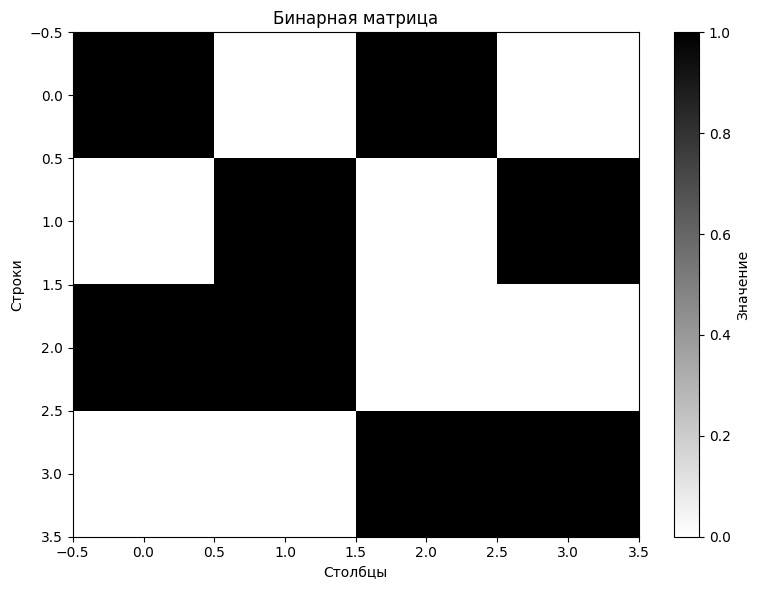

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Бинарная матрица'}, xlabel='Столбцы', ylabel='Строки'>)

In [102]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def visualize_binary_matrix(matrix, title="Бинарная матрица",
                          figsize=(8, 6), cmap='binary'):
    """
    Визуализация бинарной матрицы с помощью тепловой карты

    Параметры:
    matrix: 2D список или numpy array с бинарными значениями (0 и 1)
    title: заголовок графика
    figsize: размер фигуры (ширина, высота)
    cmap: цветовая схема (по умолчанию 'binary' - черно-белая)
    """
    # Преобразуем в numpy array, если это список
    if isinstance(matrix, list):
        matrix = np.array(matrix)

    # Создаем фигуру
    fig, ax = plt.subplots(figsize=figsize)

    # Отображаем матрицу
    im = ax.imshow(matrix, cmap=cmap, aspect='auto',
                  interpolation='nearest')

    # Добавляем цветовую шкалу
    plt.colorbar(im, ax=ax, label='Значение')

    # Настраиваем оси
    ax.set_xlabel('Столбцы')
    ax.set_ylabel('Строки')
    ax.set_title(title)

    # Добавляем сетку для лучшей видимости ячеек
    ax.set_xticks(np.arange(-0.5, matrix.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, matrix.shape[0], 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5)

    plt.tight_layout()
    plt.show()

    return fig, ax

# Пример использования
matrix = [
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [1, 1, 0, 0],
    [0, 0, 1, 1]
]

visualize_binary_matrix(all_patterns)

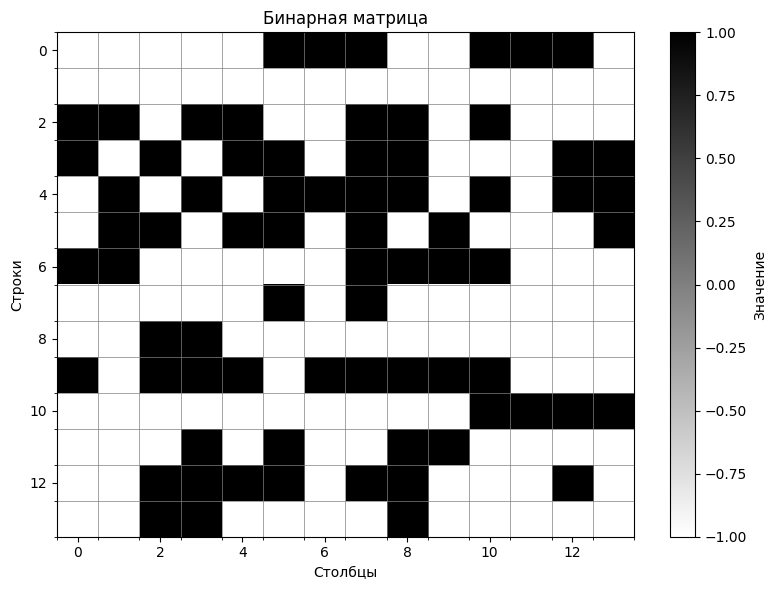

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Бинарная матрица'}, xlabel='Столбцы', ylabel='Строки'>)

In [104]:
visualize_binary_matrix(all_patterns[0].reshape(14, 14))

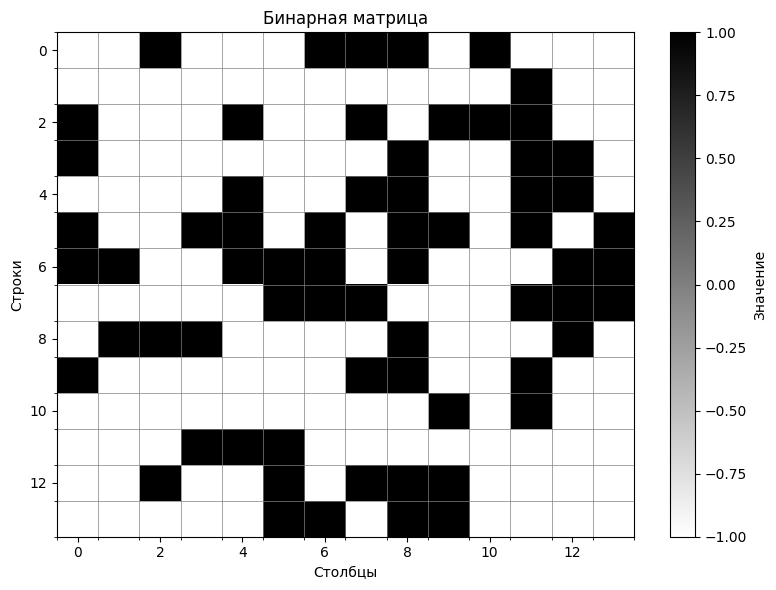

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Бинарная матрица'}, xlabel='Столбцы', ylabel='Строки'>)

In [107]:
visualize_binary_matrix(all_patterns[8].reshape(14, 14))